Veri yüklendi. Cihaz: cuda
Veri Boyutu: torch.Size([11, 5]) (H2, CO2, CH4, H2S, SO4)
Eğitim Başlıyor... (MATLAB Data Processing Kriterleri ile)
Epoch 0 | Total: 76.58828 | Data: 0.48471 | Phys: 76.10357
Epoch 1000 | Total: 0.52770 | Data: 0.52254 | Phys: 0.00516
Epoch 2000 | Total: 0.49123 | Data: 0.48446 | Phys: 0.00677
Epoch 3000 | Total: 0.47875 | Data: 0.46915 | Phys: 0.00960
Epoch 4000 | Total: 0.47067 | Data: 0.45961 | Phys: 0.01106
Epoch 5000 | Total: 0.46611 | Data: 0.45524 | Phys: 0.01087
Epoch 6000 | Total: 0.46060 | Data: 0.45190 | Phys: 0.00870
Epoch 7000 | Total: 0.46686 | Data: 0.45599 | Phys: 0.01087
Epoch 8000 | Total: 0.45029 | Data: 0.43551 | Phys: 0.01479
Epoch 9000 | Total: 0.41889 | Data: 0.40947 | Phys: 0.00942
Epoch 10000 | Total: 0.38784 | Data: 0.37300 | Phys: 0.01484
Epoch 11000 | Total: 0.41092 | Data: 0.37042 | Phys: 0.04050
Epoch 12000 | Total: 0.38618 | Data: 0.35164 | Phys: 0.03454
Epoch 13000 | Total: 0.36596 | Data: 0.34592 | Phys: 0.02004
Epoch 14000 |

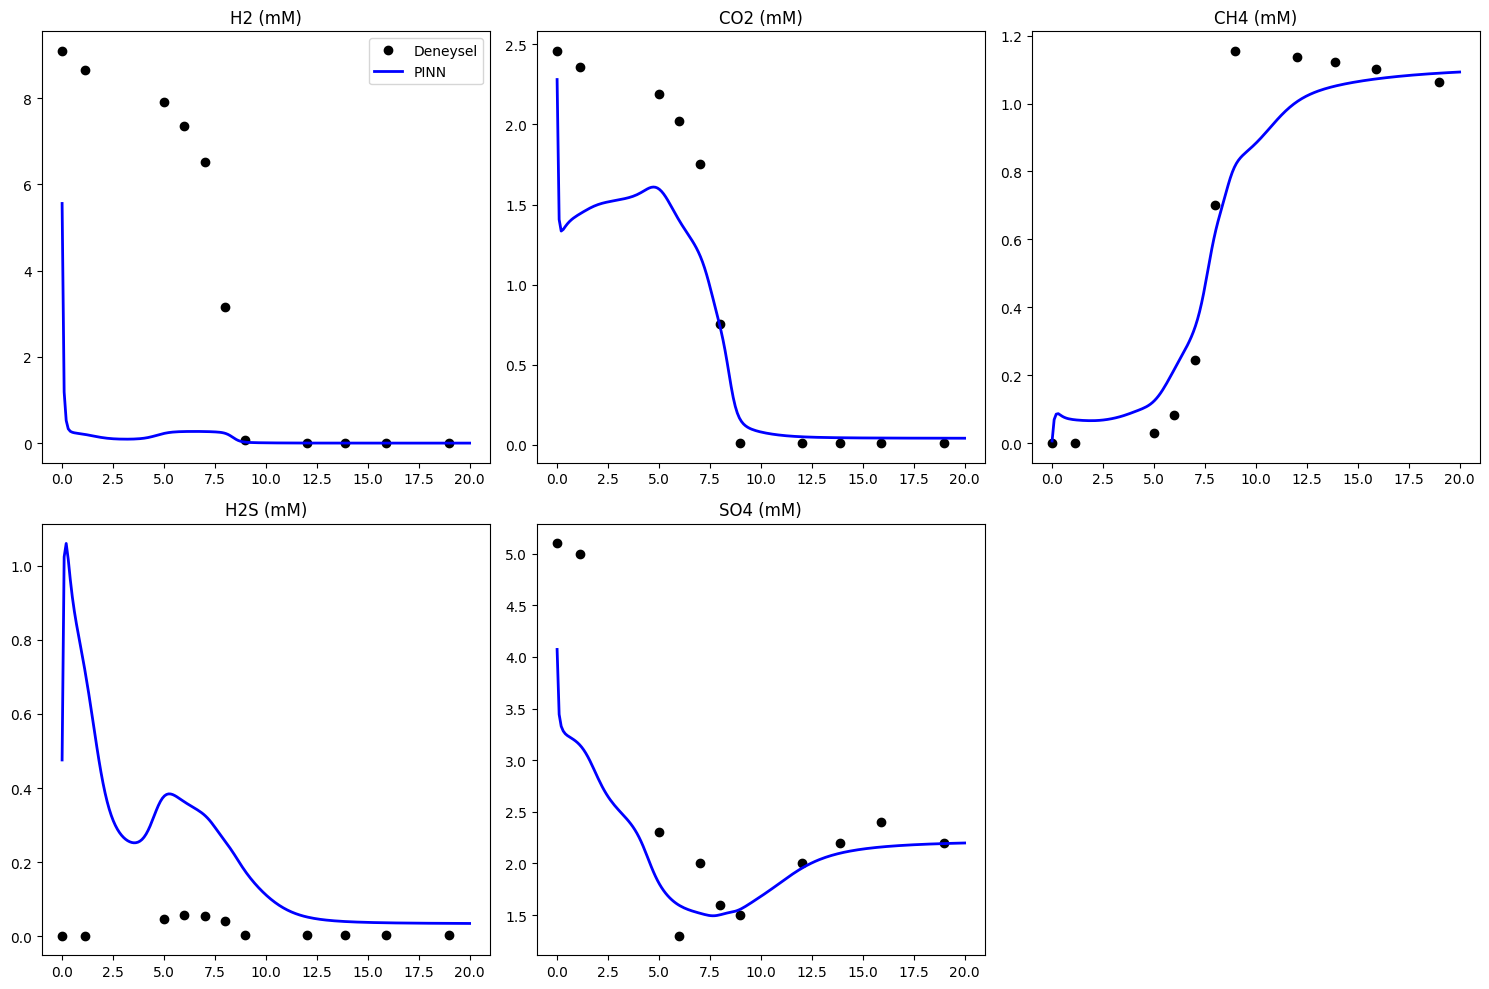

In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. VERİ OKUMA (MATLAB ile Birebir Aynı Mantık)
# ---------------------------------------------------------
def load_data(filename):
    try:
        # MATLAB: raw = readmatrix('Muller_2024_H2_Sandstone_at_25C.txt');
        # Python: Pandas ile okuyoruz.
        df = pd.read_csv(filename, sep=r'\s+', comment='%', header=None, encoding='latin-1')

        # MATLAB: t_exp = raw(:,1);
        t = df.iloc[:, 0].values.reshape(-1, 1)

        # MATLAB: data_exp = [raw(:,2:5)*1e-3, raw(:,7)];
        # Sütun İndeksleri (0 tabanlı):
        # 1=H2, 2=CO2, 3=CH4, 4=H2S (bunlar * 1e-3 olacak)
        # 6=SO4 (bu olduğu gibi alınacak)

        part1 = df.iloc[:, 1:5].values * 1e-3 # µmol -> mmol
        part2 = df.iloc[:, 6].values.reshape(-1, 1) # SO4 zaten mmol

        concs = np.hstack((part1, part2))

        return t, concs
    except Exception as e:
        print(f"Hata: {e}")
        return None, None

# Dosya yolunu kendi yolunuzla güncelleyin
filename = '/content/drive/MyDrive/chemical_thesis_repo/reactions/Matlab_codes_My_work/Muller_2024_H2_Sandstone_at_25C.txt'
t_raw, y_raw = load_data(filename)

if t_raw is not None:
    # Tensor dönüşümü (GPU varsa oraya)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    t_data = torch.tensor(t_raw, dtype=torch.float32, device=device).requires_grad_(True)
    y_data = torch.tensor(y_raw, dtype=torch.float32, device=device)

    print(f"Veri yüklendi. Cihaz: {device}")
    print(f"Veri Boyutu: {y_data.shape} (H2, CO2, CH4, H2S, SO4)")
else:
    # Dosya yoksa dummy (kod çalışsın diye)
    device = torch.device("cpu")
    t_data = torch.zeros(10, 1, requires_grad=True)
    y_data = torch.zeros(10, 5)

# ---------------------------------------------------------
# 2. PINN MODELİ
# ---------------------------------------------------------
class BioPINN(nn.Module):
    def __init__(self):
        super().__init__()

        # Standart MLP
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 10) # 10 State Variable
        )

        # MATLAB: fit_mechanistic_params içindeki LB ve UB
        self.lb = torch.tensor([0.001, 0.001, 0.001, 0.01, 0.01, 0.01, 0.001, 0.001, 0.001, 0.0, 0.0, 0.0, -50.0], device=device)
        self.ub = torch.tensor([10.0, 10.0, 10.0, 0.5, 0.5, 0.5, 10.0, 10.0, 10.0, 1.0, 1.0, 1.0, 0.0], device=device)

        # Parametreler (Latent variable olarak tanımlıyoruz)
        self.p_latent = nn.Parameter(torch.zeros(13, device=device))

    def forward(self, t):
        # Pozitiflik zorlaması (Softplus)
        return nn.functional.softplus(self.net(t))

    def get_phys_params(self):
        # Sigmoid ile LB-UB arasına sıkıştırma
        return self.lb + (self.ub - self.lb) * torch.sigmoid(self.p_latent)

# ---------------------------------------------------------
# 3. FİZİK MOTORU (MATLAB trueODEfunc_multiguild)
# ---------------------------------------------------------
def physics_loss_function(model, t):
    y = model(t)

    # Değişkenler (Burada y[:, 0:1] kullanıldığı için boyut [N, 1] kalıyor, sorun yok)
    H2      = y[:, 0:1]
    CO2     = y[:, 1:2]
    CH4     = y[:, 2:3]
    H2S     = y[:, 3:4]
    SO4     = y[:, 4:5]
    FeS     = y[:, 5:6]
    X_meth  = y[:, 6:7]
    X_sulf  = y[:, 7:8]
    X_aceto = y[:, 8:9]
    Acetate = y[:, 9:10]

    # Parametreler
    p = model.get_phys_params()
    k_meth, k_sulf, k_aceto = p[0], p[1], p[2]
    Y_m, Y_s, Y_a           = p[3], p[4], p[5]
    KI_meth, KI_sulf, KI_aceto = p[6], p[7], p[8]
    k_precip, H2S_sat       = p[9], p[10]
    H2_thresh, DG_thresh    = p[11], p[12]

    # Sabitler
    R = 8.314e-3; T = 298.15; RT = R * T
    DG0_meth = -130; DG0_sulf = -152; DG0_aceto = -95

    # Güvenlik (Sayısal Stabilite) - MATLAB: max(..., 1e-6)
    eps = 1e-6
    H2_safe  = torch.clamp(H2, min=eps)
    CO2_safe = torch.clamp(CO2, min=eps)
    CH4_safe = torch.clamp(CH4, min=eps)
    SO4_safe = torch.clamp(SO4, min=eps)
    H2S_safe = torch.clamp(H2S, min=eps)
    Acetate_safe = torch.clamp(Acetate, min=eps)

    # Ara Hesaplamalar
    f_inh_meth  = KI_meth  / (KI_meth  + H2S_safe)
    f_inh_sulf  = KI_sulf  / (KI_sulf  + H2S_safe)
    f_inh_aceto = KI_aceto / (KI_aceto + H2S_safe)

    f_activation = H2_safe / (H2_safe + H2_thresh)

    Q_meth  = CH4_safe     / (H2_safe**4 * CO2_safe)
    Q_sulf  = H2S_safe     / (H2_safe**4 * SO4_safe)
    Q_aceto = Acetate_safe / (H2_safe**4 * CO2_safe**2)

    DG_meth  = DG0_meth  + RT * torch.log(Q_meth)
    DG_sulf  = DG0_sulf  + RT * torch.log(Q_sulf)
    DG_aceto = DG0_aceto + RT * torch.log(Q_aceto)

    f_thermo_meth  = 1 / (1 + torch.exp((DG_meth  - DG_thresh)/RT))
    f_thermo_sulf  = 1 / (1 + torch.exp((DG_sulf  - DG_thresh)/RT))
    f_thermo_aceto = 1 / (1 + torch.exp((DG_aceto - DG_thresh)/RT))

    # --- REAKSİYON HIZLARI ---
    # CO2^(-2) ifadesi MATLAB ile aynı bırakıldı.
    r_meth  = k_meth  * H2_safe * (CO2_safe**(-2)) * f_inh_meth  * f_activation * f_thermo_meth
    r_sulf  = k_sulf  * H2_safe * SO4_safe         * f_inh_sulf  * f_activation * f_thermo_sulf
    r_aceto = k_aceto * H2_safe * (CO2_safe**2)    * f_inh_aceto * f_activation * f_thermo_aceto
    r_precip = k_precip * torch.relu(H2S_safe - H2S_sat)

    # --- ODELER (RHS) ---
    dH2_dt      = -4*r_meth - 4*r_sulf - 4*r_aceto
    dCO2_dt     = -1*r_meth - 2*r_aceto
    dCH4_dt     = +1*r_meth
    dH2S_dt     = +1*r_sulf - r_precip
    dSO4_dt     = -1*r_sulf
    dFeS_dt     = +1*r_precip
    dX_meth_dt  = Y_m * r_meth
    dX_sulf_dt  = Y_s * r_sulf
    dX_aceto_dt = Y_a * r_aceto
    dAcetate_dt = +1*r_aceto

    target_derivatives = torch.cat([
        dH2_dt, dCO2_dt, dCH4_dt, dH2S_dt, dSO4_dt,
        dFeS_dt, dX_meth_dt, dX_sulf_dt, dX_aceto_dt, dAcetate_dt
    ], dim=1)

    # --- MODEL TÜREVLERİ (LHS) ---
    grads = []
    for i in range(10):
        # DÜZELTME BURADA YAPILDI: y[:, i:i+1]
        # Bu sayede çıktının boyutu [N, 1] olarak korunur ve t ile uyumlu olur.
        grad = torch.autograd.grad(y[:, i:i+1], t, torch.ones_like(t), create_graph=True)[0]
        grads.append(grad)
    predicted_derivatives = torch.cat(grads, dim=1)

    return torch.mean((predicted_derivatives - target_derivatives)**2)

# ---------------------------------------------------------
# 4. EĞİTİM DÖNGÜSÜ
# ---------------------------------------------------------
model = BioPINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# MATLAB: residuals_multiguild fonksiyonundaki ağırlıklar
weights_tensor = torch.tensor([1, 1, 0.5, 0.5, 1], device=device)

loss_history = []
print("Eğitim Başlıyor... (MATLAB Data Processing Kriterleri ile)")

for epoch in range(15001):
    optimizer.zero_grad()

    # 1. DATA LOSS (MATLAB: residuals_multiguild Mantığı)
    y_pred_at_data = model(t_data)

    # MATLAB: log_sim = log1p(y_sim(:,1:5));
    log_sim = torch.log1p(y_pred_at_data[:, :5])

    # MATLAB: log_exp = log1p(data_exp);
    log_exp = torch.log1p(y_data)

    # MATLAB: res = (log_sim - log_exp) .* weights;
    res = (log_sim - log_exp) * weights_tensor
    data_loss = torch.mean(res**2)

    # 2. PHYSICS LOSS
    t_physics = torch.rand(200, 1, device=device) * 20.0
    t_physics.requires_grad_(True)
    phys_loss = physics_loss_function(model, t_physics)

    # 3. TOPLAM LOSS
    loss = 1.0 * data_loss + 1.0 * phys_loss

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | Total: {loss.item():.5f} | Data: {data_loss.item():.5f} | Phys: {phys_loss.item():.5f}")

# ---------------------------------------------------------
# 5. ÇİZİM
# ---------------------------------------------------------
t_test = torch.linspace(0, 20, 200).view(-1, 1).to(device)
with torch.no_grad():
    y_test = model(t_test).cpu().numpy()
    final_params = model.get_phys_params().cpu().numpy()

print("\nEğitilen Parametreler:")
names = ['k_meth', 'k_sulf', 'k_aceto', 'Y_m', 'Y_s', 'Y_a', 'KI_m', 'KI_s', 'KI_a', 'k_prec', 'H2S_sat', 'H2_thr', 'DG_thr']
for n, v in zip(names, final_params):
    print(f"{n}: {v:.4f}")

plt.figure(figsize=(15, 10))
species = ['H2 (mM)', 'CO2 (mM)', 'CH4 (mM)', 'H2S (mM)', 'SO4 (mM)']
t_np = t_data.cpu().detach().numpy()
y_np = y_data.cpu().detach().numpy()

for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.plot(t_np, y_np[:, i], 'ko', label='Deneysel')
    plt.plot(t_test.cpu(), y_test[:, i], 'b-', linewidth=2, label='PINN')
    plt.title(species[i])
    if i==0: plt.legend()
plt.tight_layout()
plt.show()